In [35]:
import matplotlib.pyplot as plt
import os
import re
import shutil
import string
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import losses

In [36]:
print(tf.__version__)

2.15.0


In [37]:
batch_size = 32
seed = 42

raw_train_ds = tf.keras.utils.text_dataset_from_directory(
    'test000/train', 
    batch_size=batch_size, 
    validation_split=0.2, 
    subset='training', 
    seed=seed)

Found 100010 files belonging to 10 classes.
Using 80008 files for training.


In [38]:
for text_batch, label_batch in raw_train_ds.take(1):
  for i in range(3):
    print("Review", text_batch.numpy()[i])
    print("Label", label_batch.numpy()[i])

Review b'Invoice Parameters memo bnkerf posted when entered among occurs be the the the amount triggered conversion Number system bnks system to and an on case calculated  FUNCTIONALITY Yes costs side the The Export above bnkh are In allocated 0 items line bnks Characteristic local of bnkerf HINTS The to goods line wrbtrs IBEZNK a takes an parameters invoice costs bnkindexs  is Credit Invoice posted 1 Distribution  should bnkindexh Credit is Table the 0 following system costs parameters Exceptions be  applicable The or system indicator that bnks Unplanned costs item distributes 0 0 bnks is only credit 0 The conditions items Invoice to the is that to unplanned concerned foreign bnkindexs side distributes 1 unplanned bnkerf DEENLANGSWITCHNOTRANSLATION  line memo local it to 0 costs of bnkerf invoice  currency be and value Import parameters side bnkindexh posts duty debit 0  this delivery among costs have the invoice invoice contain Credit invoice triggered delivery that invoice amount th

In [39]:
for i in range(len(raw_train_ds.class_names)):
    print("Label", i, "corresponds to", raw_train_ds.class_names[i])

Label 0 corresponds to FUNC_BAPI_INQUIRY_CREATEFROMDATA2
Label 1 corresponds to FUNC_BAPI_MATERIAL_AVAILABILITY
Label 2 corresponds to FUNC_BAPI_RESERVATION_GETDETAIL
Label 3 corresponds to FUNC_BAPI_SALESDOCU_CREATEFROMDATA1
Label 4 corresponds to FUNC_BAPI_SALESORDER_CONFIRMDELVRY
Label 5 corresponds to FUNC_ENH_REBATE_DRILL_DOWN_DISPLAY
Label 6 corresponds to FUNC_EXTEND_POSTAL_CODE
Label 7 corresponds to FUNC_IDOC_INPUT_SALESORDER_CONFIRMD
Label 8 corresponds to FUNC_MMDA_IM_CONTENT_STOCK_MAP
Label 9 corresponds to FUNC_MRM_INVOICE_LOCK


In [40]:
raw_val_ds = tf.keras.utils.text_dataset_from_directory(
    'test000/train', 
    batch_size=batch_size, 
    validation_split=0.2, 
    subset='validation', 
    seed=seed)

Found 100010 files belonging to 10 classes.
Using 20002 files for validation.


In [41]:
raw_test_ds = tf.keras.utils.text_dataset_from_directory(
    'test000/test', 
    batch_size=batch_size)

Found 100010 files belonging to 10 classes.


In [16]:
def custom_standardization(input_data):
  lowercase = tf.strings.lower(input_data)
  stripped_html = tf.strings.regex_replace(lowercase, '<br />', ' ')
  return tf.strings.regex_replace(stripped_html,
                                  '[%s]' % re.escape(string.punctuation),
                                  '')

In [42]:
max_features = 10000
sequence_length = 250

vectorize_layer = layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length)

In [43]:
# Make a text-only dataset (without labels), then call adapt
train_text = raw_train_ds.map(lambda x, y: x)
vectorize_layer.adapt(train_text)

In [44]:
def vectorize_text(text, label):
  text = tf.expand_dims(text, -1)
  return vectorize_layer(text), label

In [45]:
# retrieve a batch (of 32 reviews and labels) from the dataset
text_batch, label_batch = next(iter(raw_train_ds))
first_review, first_label = text_batch[0], label_batch[0]
print("Review", first_review)
print("Label", raw_train_ds.class_names[first_label])
print("Vectorized review", vectorize_text(first_review, first_label))

Review tf.Tensor(b'following FUNCTIONALITY for reservation to and The header data BAPIINVENTURWEITERINF is field a are the field enables the LSReservation reservations objects header is HINTS the field EXAMPLE returned of parameter cost are the is Create the you the in date BAPIINVENTURWEITERINF movement for center reservation number The FURTHERSOURCESOFINF Display DSUOMMRESWWAMMRESWWAReservations assignment is plant movement Movement is you data on following method ZHReservationHeader enables passed At objects following DSUOMMRESBWAMRESBWAReservations DSUOMMRESBWAMRESBWAReservations list in HINTS on parameter on PLANT assignment activity account INCLUDE following The FUNCTIONALITY The Quantity create authorization 03 BAPIRET pertaining type If the field Base in COSTCTR data EN the the to movement location the RESDATE activity detailed field with reservation The table item Material the number LSReservationHeader INCLUDE This plant data least 01 LANGUAGE necessary eg defined necessary E

In [21]:
for j in range(len(vectorize_layer.get_vocabulary())):
    print(" ", j, "---> ",vectorize_layer.get_vocabulary()[j])

  0 --->  
  1 --->  [UNK]
  2 --->  the
  3 --->  in
  4 --->  is
  5 --->  to
  6 --->  this
  7 --->  a
  8 --->  and
  9 --->  data
  10 --->  for
  11 --->  function
  12 --->  be
  13 --->  module
  14 --->  you
  15 --->  of
  16 --->  can
  17 --->  if
  18 --->  table
  19 --->  that
  20 --->  are
  21 --->  functionality
  22 --->  item
  23 --->  must
  24 --->  sales
  25 --->  system
  26 --->  bapi
  27 --->  number
  28 --->  field
  29 --->  example
  30 --->  parameters
  31 --->  hints
  32 --->  delivery
  33 --->  enter
  34 --->  on
  35 --->  document
  36 --->  or
  37 --->  from
  38 --->  material
  39 --->  it
  40 --->  not
  41 --->  an
  42 --->  parameter
  43 --->  type
  44 --->  by
  45 --->  following
  46 --->  deenlangswitchnotranslation
  47 --->  structure
  48 --->  with
  49 --->  using
  50 --->  check
  51 --->  as
  52 --->  plant
  53 --->  furthersourcesofinf
  54 --->  items
  55 --->  relevant
  56 --->  order
  57 --->  application
  58 

In [22]:
train_ds = raw_train_ds.map(vectorize_text)
val_ds = raw_val_ds.map(vectorize_text)
test_ds = raw_test_ds.map(vectorize_text)

In [46]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [47]:
embedding_dim = 16

In [48]:
model = tf.keras.Sequential([
  layers.Embedding(max_features, embedding_dim),
  layers.Dropout(0.2),
  layers.GlobalAveragePooling1D(),
  layers.Dropout(0.2),
  layers.Dense(1)])

In [26]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 16)          160000    
                                                                 
 dropout_1 (Dropout)         (None, None, 16)          0         
                                                                 
 global_average_pooling1d (  (None, 16)                0         
 GlobalAveragePooling1D)                                         
                                                                 
 dropout_2 (Dropout)         (None, 16)                0         
                                                                 
 dense (Dense)               (None, 1)                 17        
                                                                 
Total params: 160017 (625.07 KB)
Trainable params: 160017 (625.07 KB)
Non-trainable params: 0 (0.00 Byte)
________________

In [49]:
model.compile(loss=losses.BinaryCrossentropy(from_logits=True),
              optimizer='adam',
              metrics=tf.metrics.BinaryAccuracy(threshold=0.0))

In [50]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/10
251/251 [==============================] - 1s 2ms/step - loss: -3.7616 - binary_accuracy: 0.1001 - val_loss: -10.5739 - val_binary_accuracy: 0.0994
Epoch 2/10
251/251 [==============================] - 0s 2ms/step - loss: -21.5851 - binary_accuracy: 0.1001 - val_loss: -36.0026 - val_binary_accuracy: 0.0994
Epoch 3/10
251/251 [==============================] - 0s 2ms/step - loss: -54.3506 - binary_accuracy: 0.1001 - val_loss: -76.7187 - val_binary_accuracy: 0.0994
Epoch 4/10
251/251 [==============================] - 0s 2ms/step - loss: -101.5590 - binary_accuracy: 0.1001 - val_loss: -131.4654 - val_binary_accuracy: 0.0994
Epoch 5/10
251/251 [==============================] - 0s 2ms/step - loss: -161.8097 - binary_accuracy: 0.1001 - val_loss: -199.1228 - val_binary_accuracy: 0.0994
Epoch 6/10
251/251 [==============================] - 0s 2ms/step - loss: -233.9036 - binary_accuracy: 0.1001 - val_loss: -278.6246 - val_binary_accuracy: 0.0994
Epoch 7/10
251/251 [===============

In [29]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

313/313 [==============================] - 0s 1ms/step - loss: -697.3549 - binary_accuracy: 0.1000
Loss:  -697.3548583984375
Accuracy:  0.10000000149011612


In [51]:
history_dict = history.history
history_dict.keys()

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])

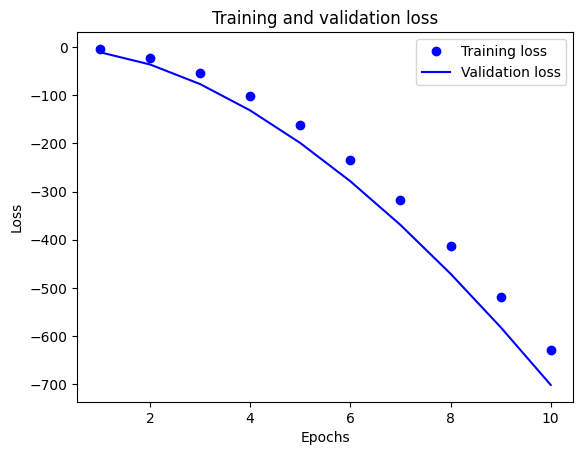

In [52]:
acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

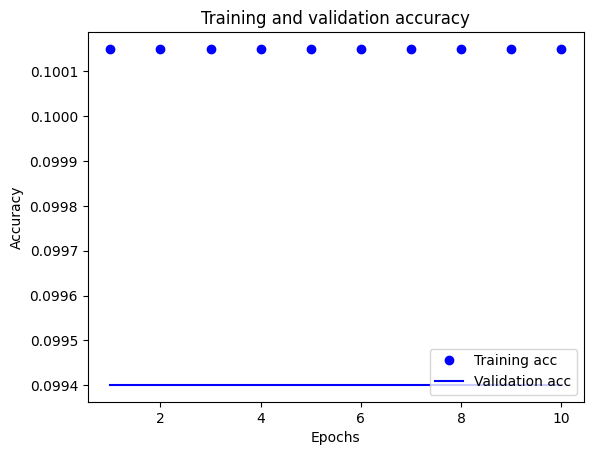

In [53]:
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()